# Create tables that compares Margin of Error and Benchmark differences for sites
In section on Phase 1 and Phase 2 indicator selection, compare CDC data. This is used in the appendix as a supplementary table in the article.

## Description of Program
- program:    tu3svi4_fv2_Phase1MOE
- task:       Create MOE table for phase 1
- Version:   
- 2025-04-27  Create MOE table for phase 1
- 2026-02-03  Changed name to be step f, added figure for one=pager
- project:    DOE Southeast Texas Urban Field Lab SVI Paper - round 4 of analysis 
- funding:	  DOE
- author:    Nathanael Rosenheim
- GRA:        Lidia Mezei

## Control Python
Add install and add packages.

In [1]:
import pandas as pd     # For obtaining and cleaning tabular data
import geopandas as gpd # For obtaining and cleaning spatial data
import numpy as np      # For working with arrays
import geopandas as gpd # For working with spatial data
import matplotlib.pyplot as plt # For plotting
import os # For saving to path

In [2]:
import sys
print("Python Version     ", sys.version)
print("geopandas version: ", gpd.__version__)

Python Version      3.10.14 | packaged by Anaconda, Inc. | (main, May  6 2024, 19:44:50) [MSC v.1916 64 bit (AMD64)]
geopandas version:  0.14.2


## Set Provenance 

In [3]:
# Get information on current working directory (getcwd)
os.getcwd()

'c:\\Users\\nathanael99\\Box\\SETx-UIFL_Team-folder\\Theme_3_eq\\Text\\SVI_Analysis_Paper\\WorkNPR'

In [4]:
# Store Program Name for SVInsightut files to have the same name and saved in the same directory
programname = "tu3svi4_6fv1_Phase1MOE_2026-02-03"
# Make directory to save output
if not os.path.exists(programname):
   os.mkdir(programname)

# Obtain Data
Obtain data from about each variable in SVI data.

In [5]:
cdcsvi_dict = {}

In [6]:
## Read in CDC SVI data 
sourcefolder = "../SourceData/www_atsdr_cdc_gov_placeandhealth_svi"
sourcefile = "CDC_2020_TX_Tract_2023-11-09.csv"
file_path = os.path.join(sourcefolder, sourcefile)
# read in file and make FIPS a string
cdcsvi_dict['TX'] = pd.read_csv(file_path, dtype={'FIPS': str})
cdcsvi_dict['TX'].head()

,ST,STATE,ST_ABBR,STCNTY,COUNTY,FIPS,LOCATION,AREA_SQMI,E_TOTPOP,M_TOTPOP,...,EP_ASIAN,MP_ASIAN,EP_AIAN,MP_AIAN,EP_NHPI,MP_NHPI,EP_TWOMORE,MP_TWOMORE,EP_OTHERRACE,MP_OTHERRACE
0,48,Texas,TX,48001,Anderson,48001950100,"Census Tract 9501, Anderson County, Texas",186.605650,4958,736,...,1.0,1.4,0.4,0.5,0.0,0.9,8.0,4.7,0.0,0.1
1,48,Texas,TX,48001,Anderson,48001950401,"Census Tract 9504.01, Anderson County, Texas",6.374261,4867,838,...,0.2,0.3,0.2,0.4,0.0,0.9,2.2,1.5,0.3,0.4
2,48,Texas,TX,48001,Anderson,48001950402,"Census Tract 9504.02, Anderson County, Texas",27.465086,7335,352,...,0.1,0.2,0.1,0.2,0.1,0.2,1.1,0.8,0.0,0.6
3,48,Texas,TX,48001,Anderson,48001950500,"Census Tract 9505, Anderson County, Texas",8.931332,4397,575,...,0.0,1.0,0.0,1.0,0.0,1.0,1.8,1.5,0.0,1.0
4,48,Texas,TX,48001,Anderson,48001950600,"Census Tract 9506, Anderson County, Texas",7.974505,4704,915,...,0.0,1.0,0.0,1.0,0.0,1.0,1.5,2.3,0.0,1.0


In [7]:
## Read in CDC SVI data 
sourcefolder = "../SourceData/www_atsdr_cdc_gov_placeandhealth_svi"
sourcefile = "CDC_2020_US_Tract_2023-11-09.csv"
file_path = os.path.join(sourcefolder, sourcefile)
# read in file and make FIPS a string
cdcsvi_dict['US'] = pd.read_csv(file_path, dtype={'FIPS': str})
cdcsvi_dict['US'].head()

,ST,STATE,ST_ABBR,STCNTY,COUNTY,FIPS,LOCATION,AREA_SQMI,E_TOTPOP,M_TOTPOP,...,EP_ASIAN,MP_ASIAN,EP_AIAN,MP_AIAN,EP_NHPI,MP_NHPI,EP_TWOMORE,MP_TWOMORE,EP_OTHERRACE,MP_OTHERRACE
0,1,Alabama,AL,1001,Autauga,01001020100,"Census Tract 201, Autauga County, Alabama",3.793570,1941,390,...,2.1,2.7,0.0,1.8,0.0,1.8,6.6,5.1,0.0,1.8
1,1,Alabama,AL,1001,Autauga,01001020200,"Census Tract 202, Autauga County, Alabama",1.282174,1757,310,...,0.0,2.0,0.0,2.0,0.0,2.0,2.6,3.0,0.8,1.1
2,1,Alabama,AL,1001,Autauga,01001020300,"Census Tract 203, Autauga County, Alabama",2.065364,3694,570,...,1.2,1.1,0.0,0.9,0.0,0.9,1.8,2.3,0.0,0.9
3,1,Alabama,AL,1001,Autauga,01001020400,"Census Tract 204, Autauga County, Alabama",2.464984,3539,500,...,0.5,0.6,0.3,0.5,0.0,1.0,2.9,2.8,0.0,1.0
4,1,Alabama,AL,1001,Autauga,01001020501,"Census Tract 205.01, Autauga County, Alabama",2.395243,4306,662,...,1.9,2.0,0.0,0.8,0.0,0.8,0.3,0.6,0.0,0.8


In [8]:
# read in original Version 1 data
sourceprogram = "tu3svi4_2av2_SVIoptions_2025-04-16"
sourcefile = sourceprogram+"/"+sourceprogram+"_all_vars_tract2020.csv"
# read in file and set ids as strings
Tract_df = pd.read_csv(sourcefile, dtype={'TRACT2020':str}, low_memory=False)

# Clean data

### Look at Benchmark Comparability
The CDC data provides examples for Texas and US. Will need to read in the original data for the US and Texas and look at the four census tracts.

In [9]:
# make list of the four census tracts with study sites
condition = Tract_df['airsite_name'].notna()
# make list of TRACT2020 with study sites
study_site_tracts = Tract_df[condition]['TRACT2020'].unique().tolist()
study_site_tracts

['48245005900', '48245006600', '48245010600', '48245005100']

In [10]:
airsite_names  = Tract_df[condition][['TRACT2020','airsite_name']].copy()
airsite_names

,TRACT2020,airsite_name
1382,48245005900,W2
1438,48245006600,E1
2283,48245010600,E2
3862,48245005100,W1


In [11]:
# use list to select tracts in CDC SVI data
condition = cdcsvi_dict['TX']['FIPS'].isin(study_site_tracts)
cdcsvi_dict['TX sites'] = cdcsvi_dict['TX'][condition].copy()

In [12]:
benchmark = 'TX'

In [13]:
# loop over benchmarks to select
for benchmark in ['TX', 'US']:
    # use list to select tracts in CDC SVI data
    condition = cdcsvi_dict[benchmark]['FIPS'].isin(study_site_tracts)
    cdcsvi_dict[f'{benchmark} sites'] = cdcsvi_dict[benchmark][condition].copy()

    var_list_dict = {}
    # loop over variables to select
    for var_list_prefix in ['E_','M_','EP_', 'MP_','EPL_', 'RPL_']:
        var_list_dict[var_list_prefix] = cdcsvi_dict[f'{benchmark} sites'].\
                                columns[cdcsvi_dict[f'{benchmark} sites'].\
                                columns.str.startswith(var_list_prefix)].tolist()

        # select desired columns
        df = cdcsvi_dict[f'{benchmark} sites'][['FIPS']+var_list_dict[var_list_prefix]].copy()

        # remove var_list_prefix from the column names
        df.columns = df.columns.str.replace(var_list_prefix, '', regex=False)

        # merge airsite names with SVI data
        df_v2 = df.merge(airsite_names, 
                            left_on='FIPS', 
                            right_on='TRACT2020', 
                            how='left')
        df_v2 = df_v2.T
        # make index a new column
        df_v2.reset_index(inplace=True)

        # use airsite name as the headings for the columns
        df_v2.columns = df_v2.iloc[-1]
        # reset index
        df_v2 = df_v2[1:]

        # rename W1 to W1_US
        df_v2.rename(columns = {'W1' : f'W1 {benchmark}',
                                'W2' : f'W2 {benchmark}',
                                'E1' : f'E1 {benchmark}',
                                'E2' : f'E2 {benchmark}',
                                'airsite_name' : 'indicator'}
                                    , inplace=True)

        # drop rows for airsite_name
        condition = df_v2['indicator'] == 'airsite_name'
        df_v2 = df_v2[~condition]
        condition = df_v2['indicator'] == 'TRACT2020'
        df_v2 = df_v2[~condition]

        # convert to float
        df_v2[f'W1 {benchmark}'] =  df_v2[f'W1 {benchmark}'].astype(float)
        df_v2[f'W2 {benchmark}'] =  df_v2[f'W2 {benchmark}'].astype(float)
        df_v2[f'E1 {benchmark}'] =  df_v2[f'E1 {benchmark}'].astype(float)
        df_v2[f'E2 {benchmark}'] =  df_v2[f'E2 {benchmark}'].astype(float)

        cdcsvi_dict[f'{benchmark} {var_list_prefix}'] = df_v2


In [14]:
cdcsvi_dict[f'TX M_'].head()

29,indicator,W1 TX,W2 TX,E1 TX,E2 TX
1,TOTPOP,319.0,366.0,887.0,660.0
2,HU,135.0,128.0,273.0,218.0
3,HH,102.0,144.0,293.0,239.0
4,POV150,309.0,265.0,756.0,681.0
5,UNEMP,31.0,75.0,92.0,96.0


In [51]:
# merge TX EP_ and MP_ dataframes
df_v3 = cdcsvi_dict['TX E_'].merge(cdcsvi_dict['TX M_'], 
                            left_on='indicator', 
                            right_on='indicator', 
                            how='left',
                            suffixes=(' E', ' M'))
    
# add confidence intervals based on E and M
# loop over site names
for site_name in ['W1', 'W2', 'E1', 'E2']:
    # calculate the standard error from MOE
    # MOE is 90% confidence interval, so divide by 1.645 to get standard error
    df_v3[f'{site_name} SE'] = df_v3[f'{site_name} TX M'] / 1.645
    # look at lower bound
    df_v3[f'{site_name} LB'] = df_v3[f'{site_name} TX E'] - df_v3[f'{site_name} TX M']   
    # look at upper bound
    df_v3[f'{site_name} UB'] = df_v3[f'{site_name} TX E'] + df_v3[f'{site_name} TX M']

    # check if lower bound is less than 0
    condition = df_v3[f'{site_name} LB'] < 0
    # if so, set lower bound to 0
    df_v3.loc[condition, f'{site_name} LB'] = 0

    # combine lower and upper bounds into a single column 
    # set format to 1 decimal place
    df_v3[f'{site_name} LB'] = df_v3[f'{site_name} LB'].map('{:.0f}'.format)
    df_v3[f'{site_name} UB'] = df_v3[f'{site_name} UB'].map('{:.0f}'.format)
    # combine lower and upper bounds into a single column
    df_v3[f'{site_name} CI'] = df_v3[f'{site_name} LB'].astype(str) + ' - ' + df_v3[f'{site_name} UB'].astype(str)
    # drop lower and upper bounds
    df_v3.drop([f'{site_name} LB', f'{site_name} UB'], axis=1, inplace=True)
    # format column with EP and CI together with a line break
    df_v3[f'{site_name} E (CI)'] = df_v3[f'{site_name} TX E'].map('{:.0f}'.format) + \
        '\n(' + df_v3[f'{site_name} CI'] + ')'

df_v3[f'W'] = df_v3[f'W1 TX E'] + df_v3[f'W2 TX E']
df_v3[f'W SE'] = np.sqrt(df_v3[f'W1 SE']**2 + df_v3[f'W2 SE']**2)
df_v3[f'E'] = df_v3[f'E1 TX E'] + df_v3[f'E2 TX E']
df_v3[f'E SE'] = np.sqrt(df_v3[f'E1 SE']**2 + df_v3[f'E2 SE']**2)
df_v3[f'W-E'] = df_v3[f'W'] - df_v3[f'E']

for i in ['1','2']:
    # Check if there is a statistically significant difference between the two estimates
    df_v3[f'W{i} - E{i}'] = df_v3[f'W{i} TX E'] - df_v3[f'E{i} TX E']
    # take the square root of the sum of the squares of the standard errors
    df_v3[f'W{i} - E{i} SE'] = np.sqrt(df_v3[f'W{i} SE']**2 + df_v3[f'E{i} SE']**2)
    # calculate the z score
    df_v3[f'W{i} - E{i} Z'] = abs(df_v3[f'W{i} - E{i}'] / df_v3[f'W{i} - E{i} SE'])
    # if z score is greater than 1.645, then there is a statistically significant difference
    # if z score is less than 1.645, then there is not a statistically significant difference
    df_v3[f'W{i} - E{i} sig'] = ''
    # give 1 star if z score is greater than 1.645
    condition = df_v3[f'W{i} - E{i} Z'] > 1.645
    df_v3.loc[condition, f'W{i} - E{i} sig'] = '*'
    # give 2 stars if z score is greater than 1.96
    condition = df_v3[f'W{i} - E{i} Z'] > 1.96
    df_v3.loc[condition, f'W{i} - E{i} sig'] = '**'
    # give 3 stars if z score is greater than 2.576
    condition = df_v3[f'W{i} - E{i} Z'] > 2.576
    df_v3.loc[condition, f'W{i} - E{i} sig'] = '***'

    # combine difference and significance stars into a single column
    df_v3[f'W{i} - E{i} v2'] = df_v3[f'W{i} - E{i}'].map('{:.1f}'.format) + df_v3[f'W{i} - E{i} sig'] 
# keep key columns
key_cols1 = ['indicator', 'W1 E (CI)', 'E1 E (CI)', 'W1 - E1 v2']
key_cols2 = ['W2 E (CI)', 'E2 E (CI)', 'W2 - E2 v2']
key_cols3 = ['W', 'E', 'W-E', 'W SE', 'E SE']
key_cols = key_cols1 + key_cols2 + key_cols3
df_v4_EM = df_v3[key_cols].copy()

df_v4_EM

,indicator,W1 E (CI),E1 E (CI),W1 - E1 v2,W2 E (CI),E2 E (CI),W2 - E2 v2,W,E,W-E,W SE,E SE
0,TOTPOP,1079\n(760 - 1398),3908\n(3021 - 4795),-2829.0***,1459\n(1093 - 1825),5633\n(4973 - 6293),-4174.0***,2538.0,9541.0,-7003.0,295.141004,672.102114
1,HU,664\n(529 - 799),2070\n(1797 - 2343),-1406.0***,754\n(626 - 882),2156\n(1938 - 2374),-1402.0***,1418.0,4226.0,-2808.0,113.091151,212.377413
2,HH,448\n(346 - 550),1597\n(1304 - 1890),-1149.0***,601\n(457 - 745),1968\n(1729 - 2207),-1367.0***,1049.0,3565.0,-2516.0,107.273735,229.856377
3,POV150,500\n(191 - 809),2457\n(1701 - 3213),-1957.0***,774\n(509 - 1039),1593\n(912 - 2274),-819.0*,1274.0,4050.0,-2776.0,247.458978,618.538270
4,UNEMP,24\n(0 - 55),163\n(71 - 255),-139.0**,76\n(1 - 151),118\n(22 - 214),-42.0,100.0,281.0,-181.0,49.333845,80.830493
5,HBURD,119\n(41 - 197),568\n(332 - 804),-449.0***,195\n(102 - 288),425\n(259 - 591),-230.0**,314.0,993.0,-679.0,73.786973,175.400746
6,NOHSDP,74\n(0 - 151),729\n(499 - 959),-655.0***,149\n(87 - 211),415\n(202 - 628),-266.0**,223.0,1144.0,-921.0,60.096343,190.564661
7,UNINSUR,197\n(7 - 387),1214\n(793 - 1635),-1017.0***,367\n(233 - 501),1422\n(884 - 1960),-1055.0***,564.0,2636.0,-2072.0,141.337059,415.284784
8,AGE65,271\n(187 - 355),333\n(228 - 438),-62.0,117\n(30 - 204),1137\n(797 - 1477),-1020.0***,388.0,1470.0,-1082.0,73.516028,216.318582
9,AGE17,183\n(69 - 297),1405\n(832 - 1978),-1222.0***,510\n(338 - 682),1216\n(923 - 1509),-706.0***,693.0,2621.0,-1928.0,125.440254,391.225911


In [53]:
# merge TX EP_ and MP_ dataframes
df_v3 = cdcsvi_dict['TX EP_'].merge(cdcsvi_dict['TX MP_'], 
                            left_on='indicator', 
                            right_on='indicator', 
                            how='left',
                            suffixes=(' EP', ' MP'))
    
# add confidence intervals based on EP and MP
# loop over site names
for site_name in ['W1', 'W2', 'E1', 'E2']:
    # calculate the standard error from MOE
    # MOE is 90% confidence interval, so divide by 1.645 to get standard error
    df_v3[f'{site_name} SE'] = df_v3[f'{site_name} TX MP'] / 1.645
    # look at lower bound
    df_v3[f'{site_name} LB'] = df_v3[f'{site_name} TX EP'] - df_v3[f'{site_name} TX MP']   
    # look at upper bound
    df_v3[f'{site_name} UB'] = df_v3[f'{site_name} TX EP'] + df_v3[f'{site_name} TX MP']

    # check if lower bound is less than 0
    condition = df_v3[f'{site_name} LB'] < 0
    # if so, set lower bound to 0
    df_v3.loc[condition, f'{site_name} LB'] = 0
    # check if upper bound is greater than 100
    condition = df_v3[f'{site_name} UB'] > 100
    # if so, set upper bound to 100
    df_v3.loc[condition, f'{site_name} UB'] = 100

    # combine lower and upper bounds into a single column 
    # set format to 1 decimal place
    df_v3[f'{site_name} LB'] = df_v3[f'{site_name} LB'].map('{:.1f}'.format)
    df_v3[f'{site_name} UB'] = df_v3[f'{site_name} UB'].map('{:.1f}'.format)
    # combine lower and upper bounds into a single column
    df_v3[f'{site_name} CI'] = df_v3[f'{site_name} LB'].astype(str) + '% - ' + df_v3[f'{site_name} UB'].astype(str) + '%'
    # drop lower and upper bounds
    #df_v3.drop([f'{site_name} LB', f'{site_name} UB'], axis=1, inplace=True)
    # format column with EP and CI together with a line break
    df_v3[f'{site_name} EP (CI)'] = df_v3[f'{site_name} TX EP'].map('{:.1f}'.format) + '%' \
         + '\n(' + df_v3[f'{site_name} CI'] + ')'

for i in ['W1','W2', 'E1','E2']:
    for j in ['W1','W2', 'E1','E2']:
        # Check if there is a statistically significant difference between the two estimates
        df_v3[f'{i} - {j}'] = df_v3[f'{i} TX EP'] - df_v3[f'{j} TX EP']
        # take the square root of the sum of the squares of the standard errors
        df_v3[f'{i} - {j} SE'] = np.sqrt(df_v3[f'{i} SE']**2 + df_v3[f'{j} SE']**2)
        # calculate the z score
        df_v3[f'{i} - {j} Z'] = abs(df_v3[f'{i} - {j}'] / df_v3[f'{i} - {j} SE'])
        # if z score is greater than 1.645, then there is a statistically significant difference
        # if z score is less than 1.645, then there is not a statistically significant difference
        df_v3[f'{i} - {j} sig'] = ''
        # give 1 star if z score is greater than 1.645
        condition = df_v3[f'{i} - {j} Z'] > 1.645
        df_v3.loc[condition, f'{i} - {j} sig'] = '*'
        # give 2 stars if z score is greater than 1.96
        condition = df_v3[f'{i} - {j} Z'] > 1.96
        df_v3.loc[condition, f'{i} - {j} sig'] = '**'
        # give 3 stars if z score is greater than 2.576
        condition = df_v3[f'{i} - {j} Z'] > 2.576
        df_v3.loc[condition, f'{i} - {j} sig'] = '***'

        # combine difference and significance stars into a single column
        df_v3[f'{i} - {j} v2'] = df_v3[f'{i} - {j}'].map('{:.1f}'.format) + \
            '%' + df_v3[f'{i} - {j} sig'] 


C:\Users\nathanael99\AppData\Local\Temp\ipykernel_30608\1308080058.py:47: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_v3[f'{i} - {j} Z'] = abs(df_v3[f'{i} - {j}'] / df_v3[f'{i} - {j} SE'])
C:\Users\nathanael99\AppData\Local\Temp\ipykernel_30608\1308080058.py:50: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_v3[f'{i} - {j} sig'] = ''
C:\Users\nathanael99\AppData\Local\Temp\ipykernel_30608\1308080058.py:62: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times,

In [17]:
# keep key columns
key_cols1 = ['indicator', 'W1 EP (CI)', 'W2 EP (CI)', ]
key_cols2 = ['E1 EP (CI)', 'E2 EP (CI)', ]
key_cols3 = ['W1 - E1 v2', 'W1 - E2 v2', 'W2 - E1 v2', 'W2 - E2 v2', 'E1 - E2 v2', 'W1 - W2 v2']
# combine key column
key_cols = key_cols1 + key_cols2 + key_cols3
df_v4 = df_v3[key_cols].copy()


In [18]:
# Create a mapping dictionary
indicator_mapping = {
    "POV150": "Below 150% Poverty",
    "UNEMP": "Unemployed",
    "HBURD": "Housing Cost Burden",
    "NOHSDP": "No High School Diploma",
    "UNINSUR": "No Health Insurance",
    "AGE65": "Aged 65 or Older",
    "SNGPNT": "Single-Parent Households",
    "AGE17": "Aged 17 or Younger",
    "LIMENG": "English Language Proficiency",
    "DISABL": "Civilian With a Disability",
    "MINRTY": "Minority",
    "MOBILE": "Mobile Homes",
    "GROUPQ": "Group Quarters",
    "MUNIT": "Multi-Unit Structures",
    "CROWD": "Crowding",
    "NOVEH": "No Vehicle",
    "NOINT": "No Broadband Internet",
    "AFAM" : "Black/African American, not Hispanic or Latino",
    "HISP" : "Hispanic or Latino",
    "ASIAN" : "Asian, not Hispanic or Latino",
    "AIAN" : "American Indian or Alaska Native, not Hispanic or Latino",
    "NHPI" : "Native Hawaiian or Other Pacific Islander, not Hispanic or Latino",
    "TWOMORE" : "Two or more races, not Hispanic or Latino",
    "OTHERRACE" :  "Some other race, not Hispanic or Latino"
}

# Map the labels to the 'indicator' column
df_v4['indicator'] = df_v4['indicator'].replace(indicator_mapping)
df_v4

26,indicator,W1 EP (CI),W2 EP (CI),E1 EP (CI),E2 EP (CI),W1 - E1 v2,W1 - E2 v2,W2 - E1 v2,W2 - E2 v2,E1 - E2 v2,W1 - W2 v2
0,Below 150% Poverty,46.9%\n(21.4% - 72.4%),55.2%\n(41.9% - 68.5%),65.5%\n(50.7% - 80.3%),28.9%\n(17.0% - 40.8%),-18.6%,18.0%,-10.3%,26.3%**,36.6%***,-8.3%
1,Unemployed,5.4%\n(0.0% - 12.5%),13.6%\n(3.0% - 24.2%),11.4%\n(5.9% - 16.9%),4.0%\n(0.6% - 7.4%),-6.0%,1.4%,2.2%,9.6%,7.4%*,-8.2%
2,Housing Cost Burden,26.6%\n(10.3% - 42.9%),32.4%\n(19.0% - 45.8%),35.6%\n(22.3% - 48.9%),21.6%\n(13.6% - 29.6%),-9.0%,5.0%,-3.2%,10.8%,14.0%,-5.8%
3,No High School Diploma,8.4%\n(1.2% - 15.6%),17.3%\n(8.9% - 25.7%),34.8%\n(26.6% - 43.0%),10.6%\n(5.4% - 15.8%),-26.4%***,-2.2%,-17.5%**,6.7%,24.2%***,-8.9%
4,No Health Insurance,18.3%\n(4.6% - 32.0%),25.2%\n(17.9% - 32.5%),31.1%\n(22.1% - 40.1%),25.7%\n(17.6% - 33.8%),-12.8%,-7.4%,-5.9%,-0.5%,5.4%,-6.9%
5,Aged 65 or Older,25.1%\n(18.7% - 31.5%),8.0%\n(2.0% - 14.0%),8.5%\n(5.4% - 11.6%),20.2%\n(14.7% - 25.7%),16.6%***,4.9%,-0.5%,-12.2%**,-11.7%***,17.1%***
6,Aged 17 or Younger,17.0%\n(7.7% - 26.3%),35.0%\n(27.1% - 42.9%),36.0%\n(23.8% - 48.2%),21.6%\n(17.1% - 26.1%),-19.0%**,-4.6%,-1.0%,13.4%**,14.4%*,-18.0%**
7,Civilian With a Disability,23.2%\n(12.6% - 33.8%),10.1%\n(5.7% - 14.5%),12.9%\n(6.8% - 19.0%),13.2%\n(9.2% - 17.2%),10.3%,10.0%,-2.8%,-3.1%,-0.3%,13.1%*
8,Single-Parent Households,6.0%\n(1.3% - 10.7%),33.4%\n(18.4% - 48.4%),20.6%\n(11.3% - 29.9%),4.1%\n(1.2% - 7.0%),-14.6%**,1.9%,12.8%,29.3%***,16.5%***,-27.4%***
9,English Language Proficiency,0.0%\n(0.0% - 5.3%),0.3%\n(0.0% - 4.1%),14.6%\n(9.1% - 20.1%),3.0%\n(0.7% - 5.3%),-14.6%***,-3.0%,-14.3%***,-2.7%,11.6%***,-0.3%


## Create benchmark comparability table

In [19]:
# merge TX EP_ and MP_ dataframes
benchmark_df = cdcsvi_dict['TX EPL_'].merge(cdcsvi_dict['US EPL_'], 
                            left_on='indicator', 
                            right_on='indicator', 
                            how='left',
                            suffixes=(' TX', ' US'))
# Map the labels to the 'indicator' column
benchmark_df['indicator'] = benchmark_df['indicator'].replace(indicator_mapping)

In [20]:
benchmark_df

18,indicator,W1 TX,W2 TX,E1 TX,E2 TX,W1 US,W2 US,E1 US,E2 US
0,Below 150% Poverty,0.8808,0.9457,0.9817,0.6343,0.9190,0.9609,0.9860,0.7157
1,Unemployed,0.5858,0.9504,0.9142,0.4305,0.5807,0.9400,0.9021,0.4210
2,Housing Cost Burden,0.5264,0.6904,0.7624,0.3686,0.5399,0.6950,0.7624,0.3730
3,No High School Diploma,0.3564,0.6194,0.8740,0.4335,0.4656,0.7728,0.9576,0.5673
4,No Health Insurance,0.5754,0.7724,0.8817,0.7831,0.8981,0.9615,0.9831,0.9641
5,Aged 65 or Older,0.9338,0.2455,0.2747,0.8397,0.8770,0.1202,0.1380,0.7228
6,Aged 17 or Younger,0.1374,0.9165,0.9350,0.3034,0.2187,0.9669,0.9745,0.4783
7,Civilian With a Disability,0.9541,0.4211,0.6008,0.6181,0.9279,0.3346,0.5289,0.5487
8,Single-Parent Households,0.4556,0.9966,0.9607,0.3091,0.5620,0.9971,0.9716,0.3889
9,English Language Proficiency,0.0000,0.1168,0.8381,0.4527,0.0000,0.2900,0.9245,0.6747


In [21]:
# add min max mean median and statistically significant difference between Texas and US
# replace -999 with Nan
benchmark_compare_df = cdcsvi_dict['US'].copy()

benchmark_compare_df.replace(-999, np.nan, inplace=True)
US_distribution = benchmark_compare_df[var_list_dict['EP_']].describe().T[['count','min', 'max', 'mean', '50%']].\
    reset_index().rename(columns={'50%':'median'}).set_index('index')
# reset index to make it a column
US_distribution.reset_index(inplace=True)
# rename columns
US_distribution.rename(columns={'index':'indicator'}, inplace=True)

# id texas observations based on the FIPS code
condition = benchmark_compare_df['ST_ABBR'].str.startswith('TX')
benchmark_compare_df['TX'] = 0
benchmark_compare_df.loc[condition, 'TX'] = 1
condition = benchmark_compare_df['TX'] == 1
TX_distribution = benchmark_compare_df[condition][var_list_dict['EP_']].describe().T[['count','min', 'max', 'mean', '50%']].\
    reset_index().rename(columns={'50%':'median'}).set_index('index')
# reset index to make it a column
TX_distribution.reset_index(inplace=True)
# rename columns
TX_distribution.rename(columns={'index':'indicator'}, inplace=True)

# look at SETX counties in tract_df
# merge tract_df with benchmark_df to ID SETX
benchmark_compare_df = benchmark_compare_df.merge(Tract_df[['TRACT2020','SETX']],
                                       left_on='FIPS', 
                                        right_on='TRACT2020', 
                                        how='left')
condition = benchmark_compare_df['SETX'] == 1
SETX_distribution = benchmark_compare_df[condition][var_list_dict['EP_']].describe().T[['count','min', 'max', 'mean', '50%']].\
    reset_index().rename(columns={'50%':'median'}).set_index('index')
# reset index to make it a column
SETX_distribution.reset_index(inplace=True)
# rename columns
SETX_distribution.rename(columns={'index':'indicator'}, inplace=True)


In [22]:
benchmark_distribution_dict = {}
# merge us and tx distributions
benchmark_distribution_dict['US TX'] = US_distribution.merge(TX_distribution,
                            left_on='indicator', 
                            right_on='indicator', 
                            suffixes=('_US', '_TX'))

# merge SETX
benchmark_distribution_dict['TX SETX'] = TX_distribution.merge(SETX_distribution, 
                            left_on='indicator', 
                            right_on='indicator', 
                            suffixes=('TX', '_SETX'))

benchmark_distribution_dict['US TX']

,indicator,count_US,min_US,max_US,mean_US,median_US,count_TX,min_TX,max_TX,mean_TX,median_TX
0,EP_POV150,84122.0,0.0,100.0,22.260361,18.9,6884.0,0.0,100.0,24.908251,22.1
1,EP_UNEMP,83455.0,0.0,100.0,5.723942,4.6,6840.0,0.0,53.4,5.469620,4.6
2,EP_HBURD,84122.0,0.0,100.0,27.229401,25.2,6884.0,0.0,100.0,27.021702,25.6
3,EP_NOHSDP,83576.0,0.0,100.0,11.957566,9.0,6848.0,0.0,100.0,16.608192,12.7
4,EP_UNINSUR,83454.0,0.0,100.0,8.805903,6.8,6838.0,0.0,70.1,17.625505,15.9
5,EP_AGE65,83598.0,0.0,100.0,16.756257,15.7,6849.0,0.0,100.0,13.364345,12.3
6,EP_AGE17,84122.0,0.0,100.0,21.637592,21.8,6884.0,0.0,57.7,24.711156,25.1
7,EP_DISABL,83454.0,0.0,100.0,13.343241,12.4,6838.0,0.0,87.5,12.076148,11.2
8,EP_SNGPNT,84122.0,0.0,100.0,6.552921,5.2,6884.0,0.0,50.0,7.743071,6.5
9,EP_LIMENG,84122.0,0.0,100.0,3.914165,1.2,6884.0,0.0,76.5,7.043129,3.5


In [23]:
benchmark_distribution_dict['TX SETX']

,indicator,countTX,minTX,maxTX,meanTX,medianTX,count_SETX,min_SETX,max_SETX,mean_SETX,median_SETX
0,EP_POV150,6884.0,0.0,100.0,24.908251,22.1,128.0,0.0,65.5,27.818750,24.80
1,EP_UNEMP,6840.0,0.0,53.4,5.469620,4.6,125.0,0.0,30.7,6.333600,5.40
2,EP_HBURD,6884.0,0.0,100.0,27.021702,25.6,128.0,0.0,48.0,22.500000,22.05
3,EP_NOHSDP,6848.0,0.0,100.0,16.608192,12.7,127.0,0.0,56.2,15.570079,13.50
4,EP_UNINSUR,6838.0,0.0,70.1,17.625505,15.9,125.0,0.0,49.6,19.089600,18.30
5,EP_AGE65,6849.0,0.0,100.0,13.364345,12.3,127.0,3.3,32.6,16.022047,16.20
6,EP_AGE17,6884.0,0.0,57.7,24.711156,25.1,128.0,0.0,41.7,24.127344,24.10
7,EP_DISABL,6838.0,0.0,87.5,12.076148,11.2,125.0,7.5,33.4,16.204800,15.90
8,EP_SNGPNT,6884.0,0.0,50.0,7.743071,6.5,128.0,0.0,39.3,8.891406,6.85
9,EP_LIMENG,6884.0,0.0,76.5,7.043129,3.5,128.0,0.0,23.2,3.340625,1.50


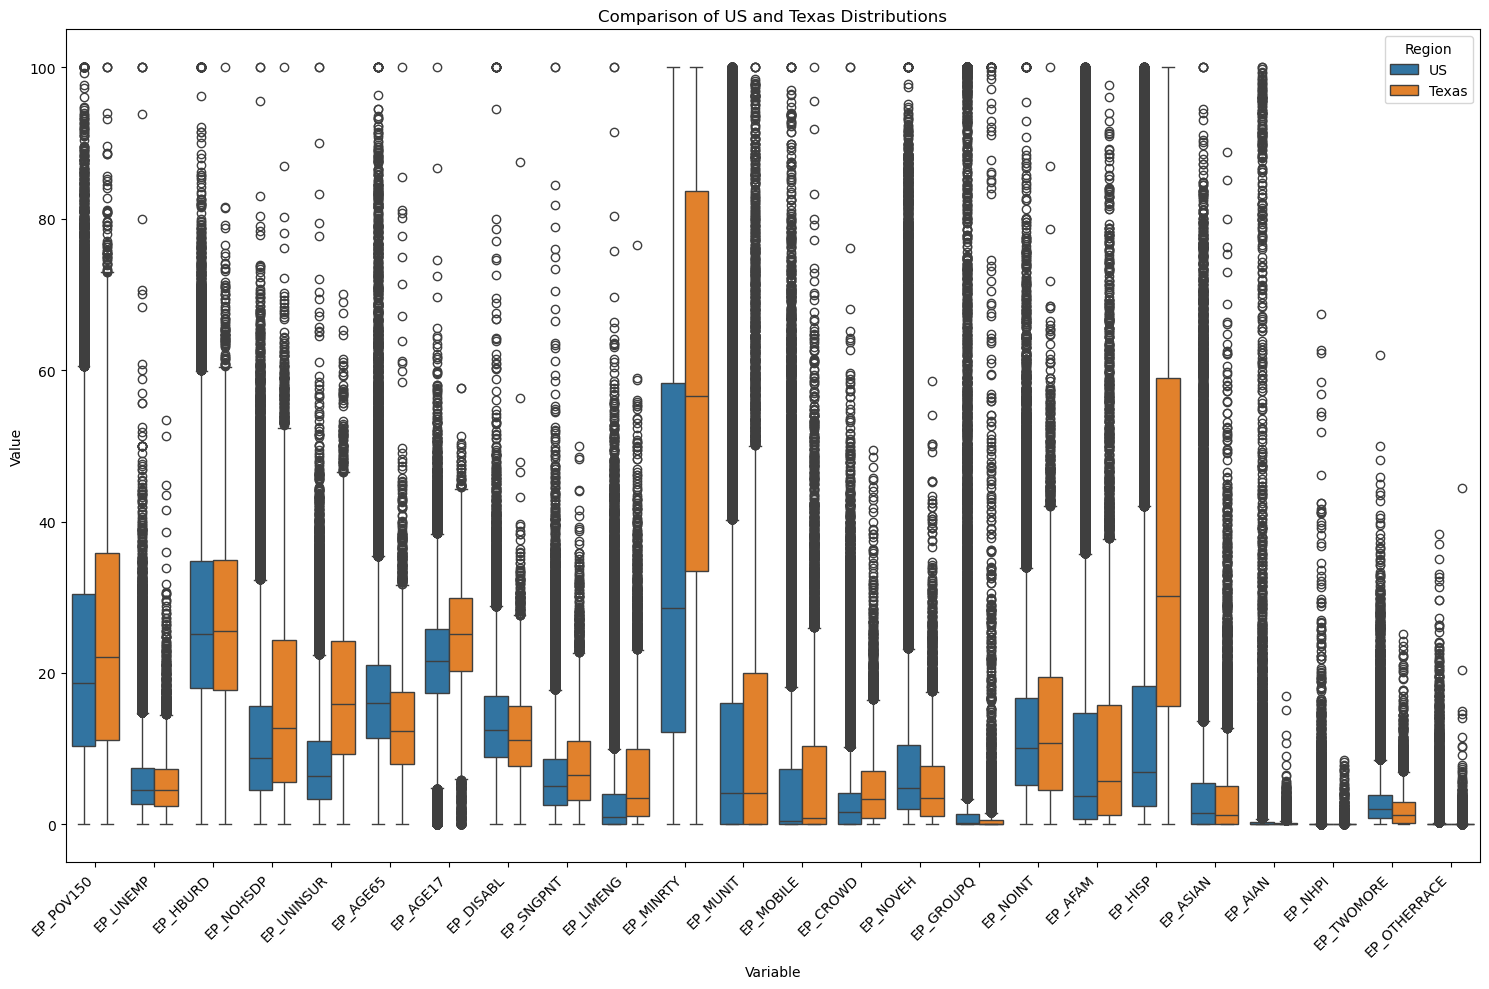

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Replace -999 with NaN
benchmark_compare_df.replace(-999, np.nan, inplace=True)

# Melt the data for easier plotting
melted_df = benchmark_compare_df.melt(
    id_vars=['TX'], 
    value_vars=var_list_dict['EP_'], 
    var_name='Variable', 
    value_name='Value'
)

# Map TX column to labels
melted_df['Region'] = melted_df['TX'].map({0: 'US', 1: 'Texas'})

# Create side-by-side box plots
plt.figure(figsize=(15, 10))
sns.boxplot(data=melted_df, x='Variable', y='Value', hue='Region')
plt.xticks(rotation=45, ha='right')
plt.title('Comparison of US and Texas Distributions')
plt.ylabel('Value')
plt.xlabel('Variable')
plt.legend(title='Region')
plt.tight_layout()
plt.show()

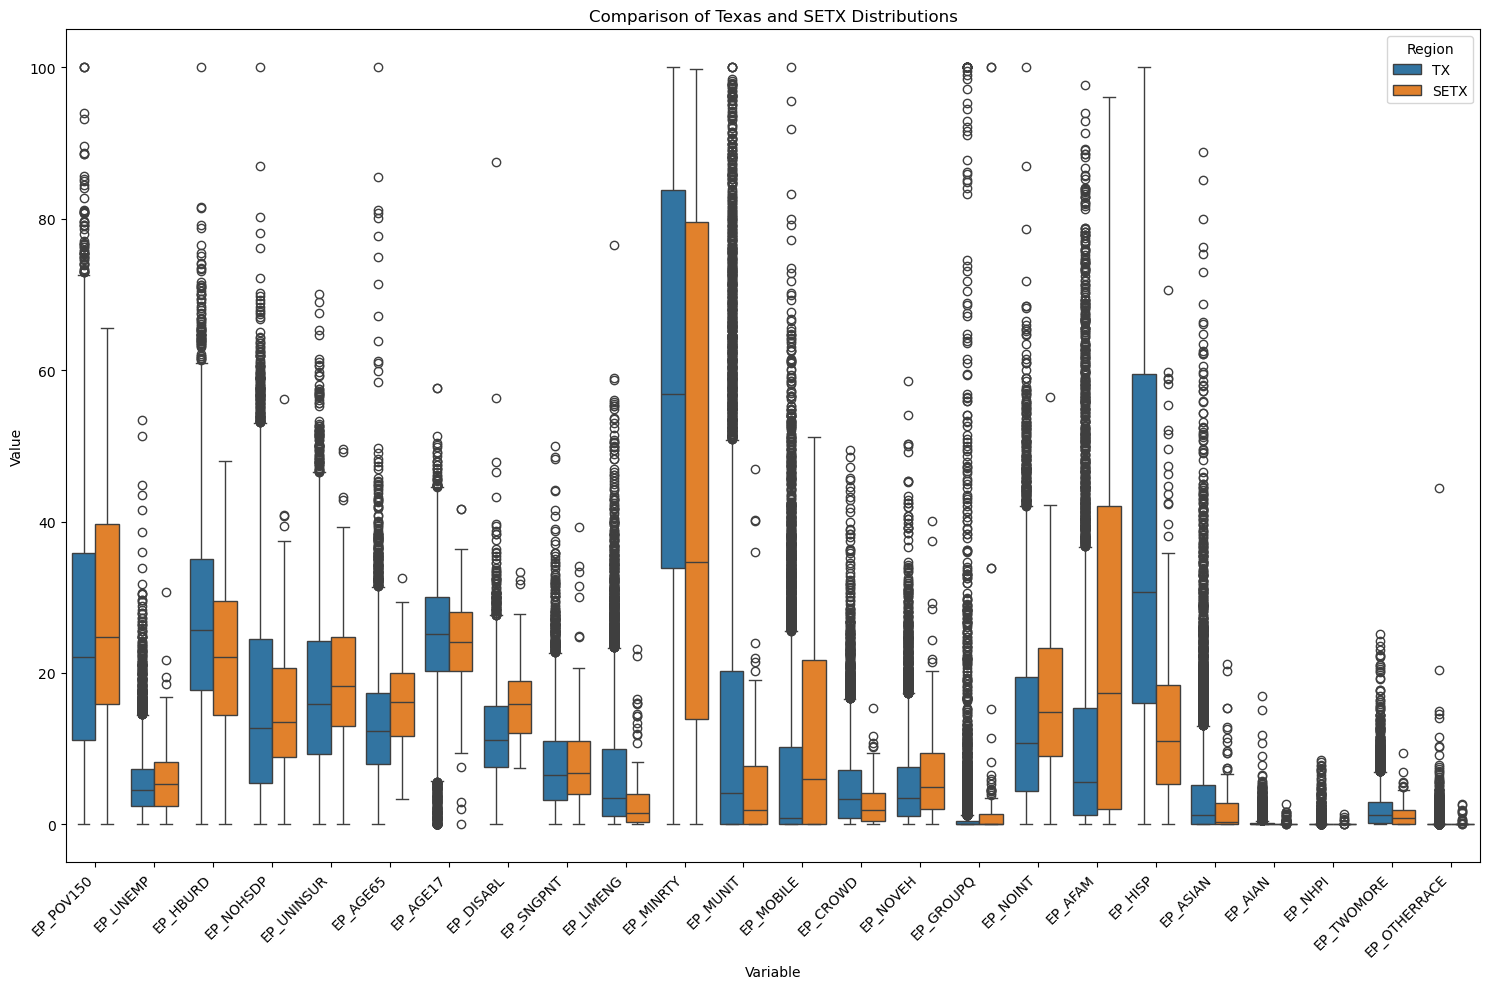

In [25]:
# Melt the data for easier plotting
melted_df = benchmark_compare_df.melt(
    id_vars=['SETX'], 
    value_vars=var_list_dict['EP_'], 
    var_name='Variable', 
    value_name='Value'
)

# Map TX column to labels
melted_df['Region'] = melted_df['SETX'].map({0: 'TX', 1: 'SETX'})

# Create side-by-side box plots
plt.figure(figsize=(15, 10))
sns.boxplot(data=melted_df, x='Variable', y='Value', hue='Region')
plt.xticks(rotation=45, ha='right')
plt.title('Comparison of Texas and SETX Distributions')
plt.ylabel('Value')
plt.xlabel('Variable')
plt.legend(title='Region')
plt.tight_layout()
plt.show()

In [26]:
from scipy.stats import ttest_ind

# Separate Texas and US data
TX_data = benchmark_compare_df[benchmark_compare_df['TX'] == 1][var_list_dict['EP_']]
US_data = benchmark_compare_df[benchmark_compare_df['TX'] == 0][var_list_dict['EP_']]

SETX_TX_data = benchmark_compare_df[benchmark_compare_df['SETX'] == 0][var_list_dict['EP_']]
SETX_data = benchmark_compare_df[benchmark_compare_df['SETX'] == 1][var_list_dict['EP_']]

# Initialize a list to store t-test results
t_test_results = []
t_test_results_SETX = []

# Perform t-test for each variable
for var in var_list_dict['EP_']:
    # Drop NaN values for the variable
    TX_values = TX_data[var].dropna()
    US_values = US_data[var].dropna()
    
    # Perform two-sample t-test
    t_stat, p_value = ttest_ind(TX_values, US_values, equal_var=False)  # Use Welch's t-test
    
    # Append results
    t_test_results.append({'indicator': var, 't-statistic US TX': round(t_stat, 3), 'p-value US TX': round(p_value, 3)})

    # Drop NaN values for the variable
    SETX_TX_values = SETX_TX_data[var].dropna()
    SETX_values = SETX_data[var].dropna()
    
    # Perform two-sample t-test
    t_stat, p_value = ttest_ind(SETX_values, SETX_TX_values, equal_var=False)  # Use Welch's t-test
    
    # Append results
    t_test_results_SETX.append({'indicator': var, 't-statistic TX SETX': round(t_stat, 3), 'p-value TX SETX': round(p_value, 3)})

# Convert results to a DataFrame
t_test_df = pd.DataFrame(t_test_results)
t_test_df_SETX = pd.DataFrame(t_test_results_SETX)

# Add t-test results to the benchmark distribution
benchmark_distribution_v2 = benchmark_distribution_dict['US TX'].merge(
    t_test_df, 
    left_on='indicator', 
    right_on='indicator', 
    how='left'
)


# sort by t-statistic
benchmark_distribution_v2.sort_values(by='t-statistic US TX', ascending=False, inplace=True)

# subtract mean of US from mean of TX
benchmark_distribution_v2['mean_diff US TX'] = benchmark_distribution_v2['mean_TX'] - \
                                      benchmark_distribution_v2['mean_US']
benchmark_distribution_v2['mean_diff US TX'] = benchmark_distribution_v2['mean_diff US TX'].round(2) 

# Map the labels to the 'indicator' column
# replace EP_ with '' in the indicator name
benchmark_distribution_v2['indicator'] = benchmark_distribution_v2['indicator'].str.replace('EP_', '', regex=False)
benchmark_distribution_v2['indicator'] = benchmark_distribution_v2['indicator'].replace(indicator_mapping)
benchmark_distribution_v2

,indicator,count_US,min_US,max_US,mean_US,median_US,count_TX,min_TX,max_TX,mean_TX,median_TX,t-statistic US TX,p-value US TX,mean_diff US TX
4,No Health Insurance,83454.0,0.0,100.0,8.805903,6.8,6838.0,0.0,70.1,17.625505,15.9,72.578,0.000,8.82
18,Hispanic or Latino,83598.0,0.0,100.0,16.953221,7.9,6849.0,0.0,100.0,38.775646,30.2,67.778,0.000,21.82
10,Minority,84122.0,0.0,100.0,38.851311,30.7,6884.0,0.0,100.0,57.196761,56.6,56.388,0.000,18.35
6,Aged 17 or Younger,84122.0,0.0,100.0,21.637592,21.8,6884.0,0.0,57.7,24.711156,25.1,33.357,0.000,3.07
9,English Language Proficiency,84122.0,0.0,100.0,3.914165,1.2,6884.0,0.0,76.5,7.043129,3.5,31.505,0.000,3.13
3,No High School Diploma,83576.0,0.0,100.0,11.957566,9.0,6848.0,0.0,100.0,16.608192,12.7,29.214,0.000,4.65
13,Crowding,84122.0,0.0,100.0,3.497571,1.7,6884.0,0.0,49.4,5.029096,3.3,23.195,0.000,1.53
8,Single-Parent Households,84122.0,0.0,100.0,6.552921,5.2,6884.0,0.0,50.0,7.743071,6.5,16.845,0.000,1.19
0,Below 150% Poverty,84122.0,0.0,100.0,22.260361,18.9,6884.0,0.0,100.0,24.908251,22.1,13.709,0.000,2.65
16,No Broadband Internet,84122.0,0.0,100.0,12.356878,10.1,6884.0,0.0,100.0,13.561389,10.7,9.059,0.000,1.20


In [27]:
# Add t-test results to the benchmark distribution
benchmark_distribution_v3 = benchmark_distribution_dict['TX SETX'].merge(
    t_test_df_SETX, 
    left_on='indicator', 
    right_on='indicator', 
    how='left'
)

# sort by t-statistic
benchmark_distribution_v3.sort_values(by='t-statistic TX SETX', ascending=False, inplace=True)

In [28]:

# subtract mean of US from mean of TX
benchmark_distribution_v3['mean_diff TX SETX'] = benchmark_distribution_v3['mean_SETX'] - \
                                      benchmark_distribution_v3['meanTX']
benchmark_distribution_v3['mean_diff TX SETX'] = benchmark_distribution_v3['mean_diff TX SETX'].round(2)  

# Map the labels to the 'indicator' column
# replace EP_ with '' in the indicator name
benchmark_distribution_v3['indicator'] = benchmark_distribution_v3['indicator'].str.replace('EP_', '', regex=False)
benchmark_distribution_v3['indicator'] = benchmark_distribution_v3['indicator'].replace(indicator_mapping)
benchmark_distribution_v3

,indicator,countTX,minTX,maxTX,meanTX,medianTX,count_SETX,min_SETX,max_SETX,mean_SETX,median_SETX,t-statistic TX SETX,p-value TX SETX,mean_diff TX SETX
7,Civilian With a Disability,6838.0,0.0,87.5,12.076148,11.2,125.0,7.5,33.4,16.204800,15.90,9.017,0.000,4.13
17,"Black/African American, not Hispanic or Latino",6849.0,0.0,97.7,11.696540,5.7,127.0,0.0,96.0,26.211024,17.30,6.114,0.000,14.51
5,Aged 65 or Older,6849.0,0.0,100.0,13.364345,12.3,127.0,3.3,32.6,16.022047,16.20,5.396,0.000,2.66
12,Mobile Homes,6828.0,0.0,100.0,7.426172,0.9,125.0,0.0,51.1,11.951200,6.00,3.756,0.000,4.53
16,No Broadband Internet,6884.0,0.0,100.0,13.561389,10.7,128.0,0.0,56.4,16.870313,14.85,3.495,0.001,3.31
14,No Vehicle,6828.0,0.0,58.5,5.505858,3.5,125.0,0.0,40.1,7.101600,4.90,2.443,0.016,1.60
0,Below 150% Poverty,6884.0,0.0,100.0,24.908251,22.1,128.0,0.0,65.5,27.818750,24.80,2.110,0.037,2.91
1,Unemployed,6840.0,0.0,53.4,5.469620,4.6,125.0,0.0,30.7,6.333600,5.40,1.974,0.051,0.86
8,Single-Parent Households,6884.0,0.0,50.0,7.743071,6.5,128.0,0.0,39.3,8.891406,6.85,1.785,0.077,1.15
4,No Health Insurance,6838.0,0.0,70.1,17.625505,15.9,125.0,0.0,49.6,19.089600,18.30,1.771,0.079,1.46


In [29]:
keep_cols = ['indicator', 'mean_US', 'mean_TX', 'mean_diff US TX', 't-statistic US TX', 'p-value US TX']
# merge benchmark_df with benchmark_distribution
benchmark_df_dist = benchmark_df.merge(benchmark_distribution_v2[keep_cols], 
                            left_on='indicator', 
                            right_on='indicator', 
                            how='left')

keep_cols = ['indicator', 'mean_SETX', 'mean_diff TX SETX', 't-statistic TX SETX', 'p-value TX SETX']
# merge benchmark_df with benchmark_distribution
benchmark_df_dist = benchmark_df_dist.merge(benchmark_distribution_v3[keep_cols], 
                            left_on='indicator', 
                            right_on='indicator', 
                            how='left')

benchmark_df_dist

,indicator,W1 TX,W2 TX,E1 TX,E2 TX,W1 US,W2 US,E1 US,E2 US,mean_US,mean_TX,mean_diff US TX,t-statistic US TX,p-value US TX,mean_SETX,mean_diff TX SETX,t-statistic TX SETX,p-value TX SETX
0,Below 150% Poverty,0.8808,0.9457,0.9817,0.6343,0.9190,0.9609,0.9860,0.7157,22.260361,24.908251,2.65,13.709,0.000,27.818750,2.91,2.110,0.037
1,Unemployed,0.5858,0.9504,0.9142,0.4305,0.5807,0.9400,0.9021,0.4210,5.723942,5.469620,-0.25,-4.925,0.000,6.333600,0.86,1.974,0.051
2,Housing Cost Burden,0.5264,0.6904,0.7624,0.3686,0.5399,0.6950,0.7624,0.3730,27.229401,27.021702,-0.21,-1.413,0.158,22.500000,-4.52,-4.926,0.000
3,No High School Diploma,0.3564,0.6194,0.8740,0.4335,0.4656,0.7728,0.9576,0.5673,11.957566,16.608192,4.65,29.214,0.000,15.570079,-1.04,-1.221,0.224
4,No Health Insurance,0.5754,0.7724,0.8817,0.7831,0.8981,0.9615,0.9831,0.9641,8.805903,17.625505,8.82,72.578,0.000,19.089600,1.46,1.771,0.079
5,Aged 65 or Older,0.9338,0.2455,0.2747,0.8397,0.8770,0.1202,0.1380,0.7228,16.756257,13.364345,-3.39,-37.031,0.000,16.022047,2.66,5.396,0.000
6,Aged 17 or Younger,0.1374,0.9165,0.9350,0.3034,0.2187,0.9669,0.9745,0.4783,21.637592,24.711156,3.07,33.357,0.000,24.127344,-0.58,-0.940,0.349
7,Civilian With a Disability,0.9541,0.4211,0.6008,0.6181,0.9279,0.3346,0.5289,0.5487,13.343241,12.076148,-1.27,-17.963,0.000,16.204800,4.13,9.017,0.000
8,Single-Parent Households,0.4556,0.9966,0.9607,0.3091,0.5620,0.9971,0.9716,0.3889,6.552921,7.743071,1.19,16.845,0.000,8.891406,1.15,1.785,0.077
9,English Language Proficiency,0.0000,0.1168,0.8381,0.4527,0.0000,0.2900,0.9245,0.6747,3.914165,7.043129,3.13,31.505,0.000,3.340625,-3.70,-8.706,0.000


In [30]:
# RPL themes
RPL_themes_df = cdcsvi_dict[f'TX RPL_'].merge(cdcsvi_dict[f'US RPL_'],
                            left_on='indicator', 
                            right_on='indicator', 
                            how='left',
                            suffixes=(' TX', ' US'))
RPL_themes_df

7,indicator,W1 TX,W2 TX,E1 TX,E2 TX,W1 US,W2 US,E1 US,E2 US
0,THEME1,0.6252,0.9015,0.9763,0.5443,0.7656,0.9609,0.9896,0.6679
1,THEME2,0.4805,0.5950,0.9487,0.4999,0.5688,0.6422,0.9584,0.7027
2,THEME3,0.9426,0.9065,0.8055,0.3059,0.9691,0.9521,0.9015,0.5790
3,THEME4,0.1008,0.4371,0.7817,0.6804,0.0624,0.4093,0.8060,0.6568
4,THEMES,0.4416,0.7561,0.9646,0.5581,0.5219,0.8294,0.9808,0.7121


In [31]:
# Concatenate benchmark_df_dist and RPL_themes_df
benchmark_df_dist_v2 = pd.concat([benchmark_df_dist, RPL_themes_df], ignore_index=True)
# subtract W1 US from W1 TX
benchmark_df_dist_v2['W1_diff'] = benchmark_df_dist_v2['W1 TX'] - benchmark_df_dist_v2['W1 US']
# subtract W2 US from W2 TX
benchmark_df_dist_v2['W2_diff'] = benchmark_df_dist_v2['W2 TX'] - benchmark_df_dist_v2['W2 US']
# subtract E1 US from E1 TX
benchmark_df_dist_v2['E1_diff'] = benchmark_df_dist_v2['E1 TX'] - benchmark_df_dist_v2['E1 US']
# subtract E2 US from E2 TX
benchmark_df_dist_v2['E2_diff'] = benchmark_df_dist_v2['E2 TX'] - benchmark_df_dist_v2['E2 US']
# sum differences and divide by 4
benchmark_df_dist_v2['PCL_mean_diff'] = abs((benchmark_df_dist_v2['W1_diff'] + 
                                       benchmark_df_dist_v2['W2_diff'] + 
                                       benchmark_df_dist_v2['E1_diff'] + 
                                       benchmark_df_dist_v2['E2_diff']) / 4)
# round everything to 3 decimal places
benchmark_df_dist_v2 = benchmark_df_dist_v2.round(3)
# sort by PCL_mean_diff
benchmark_df_dist_v2.sort_values(by='PCL_mean_diff', ascending=False, inplace=True)
benchmark_df_dist_v2

,indicator,W1 TX,W2 TX,E1 TX,E2 TX,W1 US,W2 US,E1 US,E2 US,mean_US,...,p-value US TX,mean_SETX,mean_diff TX SETX,t-statistic TX SETX,p-value TX SETX,W1_diff,W2_diff,E1_diff,E2_diff,PCL_mean_diff
4,No Health Insurance,0.575,0.772,0.882,0.783,0.898,0.962,0.983,0.964,8.806,...,0.000,19.090,1.46,1.771,0.079,-0.323,-0.189,-0.101,-0.181,0.199
9,English Language Proficiency,0.000,0.117,0.838,0.453,0.000,0.290,0.924,0.675,3.914,...,0.000,3.341,-3.70,-8.706,0.000,0.000,-0.173,-0.086,-0.222,0.120
3,No High School Diploma,0.356,0.619,0.874,0.434,0.466,0.773,0.958,0.567,11.958,...,0.000,15.570,-1.04,-1.221,0.224,-0.109,-0.153,-0.084,-0.134,0.120
10,Minority,0.943,0.906,0.806,0.306,0.969,0.952,0.902,0.579,38.851,...,0.000,45.532,-11.66,-3.980,0.000,-0.026,-0.046,-0.096,-0.273,0.110
18,THEME3,0.943,0.906,0.806,0.306,0.969,0.952,0.902,0.579,NaN,...,NaN,NaN,NaN,NaN,NaN,-0.026,-0.046,-0.096,-0.273,0.110
5,Aged 65 or Older,0.934,0.246,0.275,0.840,0.877,0.120,0.138,0.723,16.756,...,0.000,16.022,2.66,5.396,0.000,0.057,0.125,0.137,0.117,0.109
6,Aged 17 or Younger,0.137,0.916,0.935,0.303,0.219,0.967,0.974,0.478,21.638,...,0.000,24.127,-0.58,-0.940,0.349,-0.081,-0.050,-0.039,-0.175,0.087
17,THEME2,0.480,0.595,0.949,0.500,0.569,0.642,0.958,0.703,NaN,...,NaN,NaN,NaN,NaN,NaN,-0.088,-0.047,-0.010,-0.203,0.087
16,THEME1,0.625,0.902,0.976,0.544,0.766,0.961,0.990,0.668,NaN,...,NaN,NaN,NaN,NaN,NaN,-0.140,-0.059,-0.013,-0.124,0.084
20,THEMES,0.442,0.756,0.965,0.558,0.522,0.829,0.981,0.712,NaN,...,NaN,NaN,NaN,NaN,NaN,-0.080,-0.073,-0.016,-0.154,0.081


In [55]:
# list all columns in df_v3
df_v3.columns.tolist()

['indicator',
 'W1 TX EP',
 'W2 TX EP',
 'E1 TX EP',
 'E2 TX EP',
 'W1 TX MP',
 'W2 TX MP',
 'E1 TX MP',
 'E2 TX MP',
 'W1 SE',
 'W1 LB',
 'W1 UB',
 'W1 CI',
 'W1 EP (CI)',
 'W2 SE',
 'W2 LB',
 'W2 UB',
 'W2 CI',
 'W2 EP (CI)',
 'E1 SE',
 'E1 LB',
 'E1 UB',
 'E1 CI',
 'E1 EP (CI)',
 'E2 SE',
 'E2 LB',
 'E2 UB',
 'E2 CI',
 'E2 EP (CI)',
 'W1 - W1',
 'W1 - W1 SE',
 'W1 - W1 Z',
 'W1 - W1 sig',
 'W1 - W1 v2',
 'W1 - W2',
 'W1 - W2 SE',
 'W1 - W2 Z',
 'W1 - W2 sig',
 'W1 - W2 v2',
 'W1 - E1',
 'W1 - E1 SE',
 'W1 - E1 Z',
 'W1 - E1 sig',
 'W1 - E1 v2',
 'W1 - E2',
 'W1 - E2 SE',
 'W1 - E2 Z',
 'W1 - E2 sig',
 'W1 - E2 v2',
 'W2 - W1',
 'W2 - W1 SE',
 'W2 - W1 Z',
 'W2 - W1 sig',
 'W2 - W1 v2',
 'W2 - W2',
 'W2 - W2 SE',
 'W2 - W2 Z',
 'W2 - W2 sig',
 'W2 - W2 v2',
 'W2 - E1',
 'W2 - E1 SE',
 'W2 - E1 Z',
 'W2 - E1 sig',
 'W2 - E1 v2',
 'W2 - E2',
 'W2 - E2 SE',
 'W2 - E2 Z',
 'W2 - E2 sig',
 'W2 - E2 v2',
 'E1 - W1',
 'E1 - W1 SE',
 'E1 - W1 Z',
 'E1 - W1 sig',
 'E1 - W1 v2',
 'E1 - W2',
 '

In [57]:
df_v3[['indicator', 'W1 TX EP',
 'W2 TX EP',
 'E1 TX EP',
 'E2 TX EP', 'W1 LB', 'W2 LB', 'E1 LB', 'E2 LB',
 'W1 UB', 'W2 UB', 'E1 UB', 'E2 UB']].head(30)

26,indicator,W1 TX EP,W2 TX EP,E1 TX EP,E2 TX EP,W1 LB,W2 LB,E1 LB,E2 LB,W1 UB,W2 UB,E1 UB,E2 UB
0,POV150,46.9,55.2,65.5,28.9,21.4,41.9,50.7,17.0,72.4,68.5,80.3,40.8
1,UNEMP,5.4,13.6,11.4,4.0,0.0,3.0,5.9,0.6,12.5,24.2,16.9,7.4
2,HBURD,26.6,32.4,35.6,21.6,10.3,19.0,22.3,13.6,42.9,45.8,48.9,29.6
3,NOHSDP,8.4,17.3,34.8,10.6,1.2,8.9,26.6,5.4,15.6,25.7,43.0,15.8
4,UNINSUR,18.3,25.2,31.1,25.7,4.6,17.9,22.1,17.6,32.0,32.5,40.1,33.8
5,AGE65,25.1,8.0,8.5,20.2,18.7,2.0,5.4,14.7,31.5,14.0,11.6,25.7
6,AGE17,17.0,35.0,36.0,21.6,7.7,27.1,23.8,17.1,26.3,42.9,48.2,26.1
7,DISABL,23.2,10.1,12.9,13.2,12.6,5.7,6.8,9.2,33.8,14.5,19.0,17.2
8,SNGPNT,6.0,33.4,20.6,4.1,1.3,18.4,11.3,1.2,10.7,48.4,29.9,7.0
9,LIMENG,0.0,0.3,14.6,3.0,0.0,0.0,9.1,0.7,5.3,4.1,20.1,5.3


### Save output as csv

In [50]:
# save as csv
df_v3.to_csv(programname+"/"+programname+"_v3.csv", index=False)
df_v4.to_csv(programname+"/"+programname+"_MOE.csv", index=False)
df_v4_EM.to_csv(programname+"/"+programname+"_EM_MOE.csv", index=False)
benchmark_df_dist_v2.to_csv(programname+"/"+programname+"_benchmarkv2.csv", index=False)

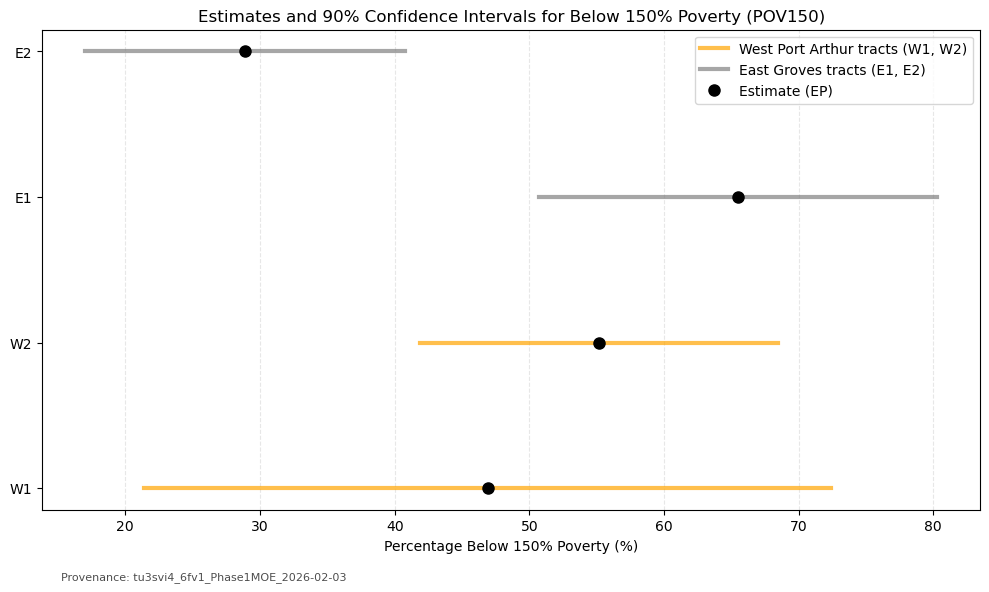

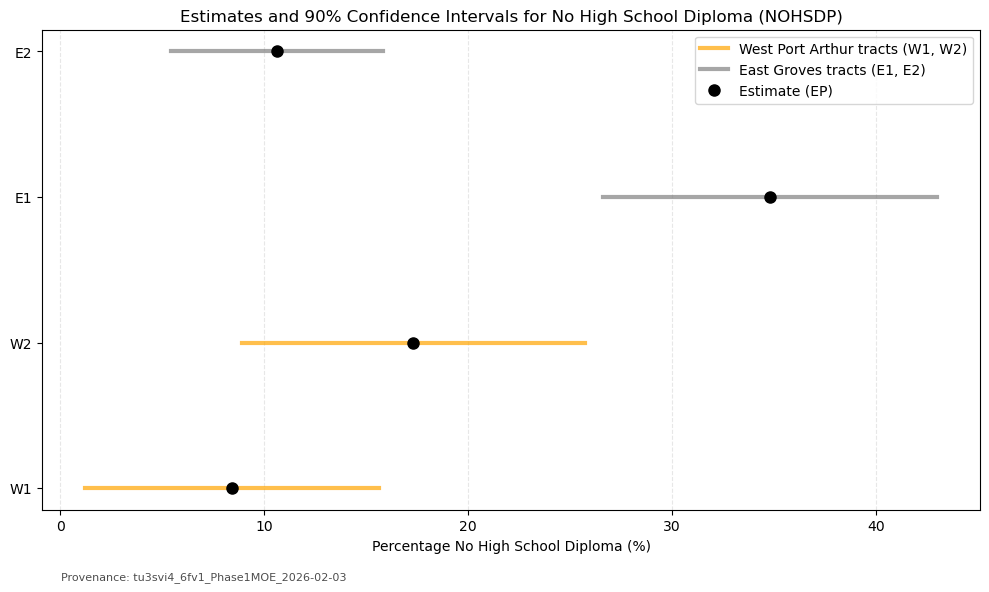

In [65]:
def plot_confidence_intervals(indicator_code, df_data, indicator_mapping):
    """
    Create a confidence interval plot for a given indicator
    
    Parameters:
    indicator_code (str): The indicator code (e.g., 'POV150', 'NOHSDP')
    df_data (DataFrame): The dataframe containing the data
    indicator_mapping (dict): Dictionary mapping indicator codes to readable names
    """
    # Get data for the specified indicator
    indicator_data = df_data[df_data['indicator'] == indicator_code].iloc[0]
    
    # Data for plotting
    sites = ['W1', 'W2', 'E1', 'E2']
    estimates = [indicator_data['W1 TX EP'], indicator_data['W2 TX EP'], 
                indicator_data['E1 TX EP'], indicator_data['E2 TX EP']]
    
    # Calculate lower and upper bounds from estimates and margins of error
    lower_bounds = []
    upper_bounds = []
    for site in sites:
        estimate = indicator_data[f'{site} TX EP']
        margin_error = indicator_data[f'{site} TX MP']
        lower_bound = estimate - margin_error
        upper_bound = estimate + margin_error
        
        # Ensure bounds are within reasonable limits (0-100%)
        lower_bound = max(0, lower_bound)
        upper_bound = min(100, upper_bound)
        
        lower_bounds.append(lower_bound)
        upper_bounds.append(upper_bound)
    
    colors = ['orange', 'orange', 'grey', 'grey']
    
    # Create the plot
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Plot confidence interval lines
    for i in range(len(sites)):
        ax.plot([lower_bounds[i], upper_bounds[i]], [i, i], color=colors[i], linewidth=3, alpha=0.7)
    
    # Plot estimates as dots
    for i in range(len(sites)):
        ax.plot(estimates[i], i, 'o', color='black', markersize=8)
    
    # Set y-axis labels
    ax.set_yticks(range(len(sites)))
    ax.set_yticklabels(sites)
    
    # Add a legend
    ax.plot([], [], color='orange', linewidth=3, alpha=0.7, label='West Port Arthur tracts (W1, W2)')
    ax.plot([], [], color='grey', linewidth=3, alpha=0.7, label='East Groves tracts (E1, E2)')
    ax.plot([], [], 'o', color='black', markersize=8, label='Estimate (EP)')
    
    # Get readable name for the indicator
    readable_name = indicator_mapping.get(indicator_code, indicator_code)
    
    ax.set_xlabel(f'Percentage {readable_name} (%)')
    ax.set_title(f'Estimates and 90% Confidence Intervals for {readable_name} ({indicator_code})')
    ax.legend()
    ax.grid(axis='x', linestyle='--', alpha=0.3)
    
    # Add provenance note below x-axis label
    ax.text(0.02, -0.15, f"Provenance: {programname}", transform=ax.transAxes, 
            fontsize=8, alpha=0.7, verticalalignment='bottom')
    
    plt.tight_layout()
    plt.show()

# Test the function with POV150 and NOHSDP
plot_confidence_intervals('POV150', df_v3, indicator_mapping)
plot_confidence_intervals('NOHSDP', df_v3, indicator_mapping)